In [ ]:
!pip install statsmodels

In [ ]:
!pip install wquantiles

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean #Media truncada
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

Diccionario
* State: Los estados analizados de los EEUU. String
* Population: Cantidad de habitantes de cada estado. Tipo Numerico - Discreto
* Murder.Rate: Tasa de homicidios en cada estado. Tipo de dato: Numerico
Discreto.
* Abbrevation: Abrevaciones de cada uno de los estados: Tipo de dato: String


In [ ]:
archivo = "/content/drive/MyDrive/Ciencia De Datos/Archivos/state.csv"
estado = pd.read_csv(archivo)

In [ ]:
estado.sample(10)

,State,Population,Murder.Rate,Abbreviation
32,North Carolina,9535483,5.1,NC
49,Wyoming,563626,2.7,WY
7,Delaware,897934,5.8,DE
14,Iowa,3046355,1.9,IA
1,Alaska,710231,5.6,AK
22,Minnesota,5303925,1.6,MN
15,Kansas,2853118,3.1,KS
0,Alabama,4779736,5.7,AL
34,Ohio,11536504,4.0,OH
42,Texas,25145561,4.4,TX


In [ ]:
estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


In [ ]:
estado.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


**Estimar la tasa de poblacion y asesinatos**

In [ ]:
estado['Population'].mean()

np.float64(6162876.3)

In [ ]:
trim_mean(estado.Population,0.1)

np.float64(4783697.125)

In [ ]:
estado.Population.median()

4436369.5

**Media ponderada de tasa de asesinatos**

In [ ]:
np.average(estado['Murder.Rate'],weights=estado['Population'])

np.float64(4.445833981123393)

**Mediana ponderada de tasa de asesinatos**

In [ ]:
wquantiles.median(estado['Murder.Rate'],weights=estado['Population'])

np.float64(4.4)

<Axes: >

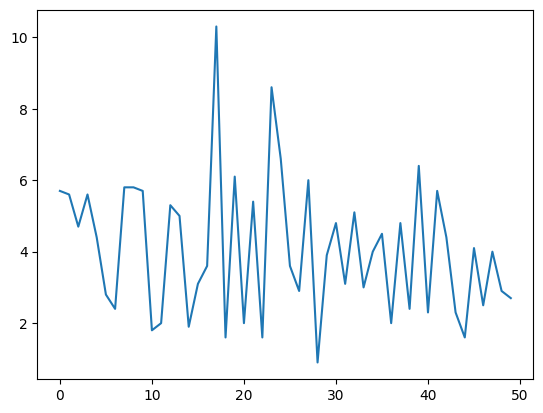

In [ ]:
estado["Murder.Rate"].plot.line()

<Axes: >

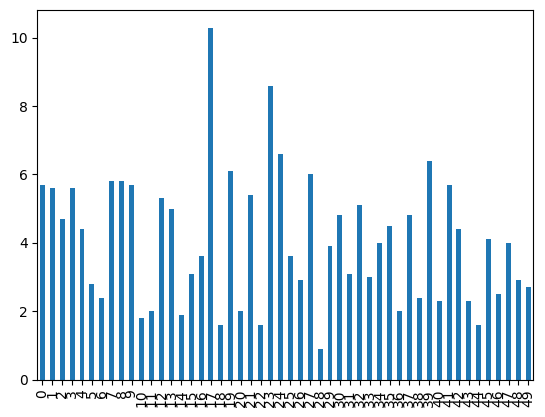

In [ ]:
estado["Murder.Rate"].plot.bar()

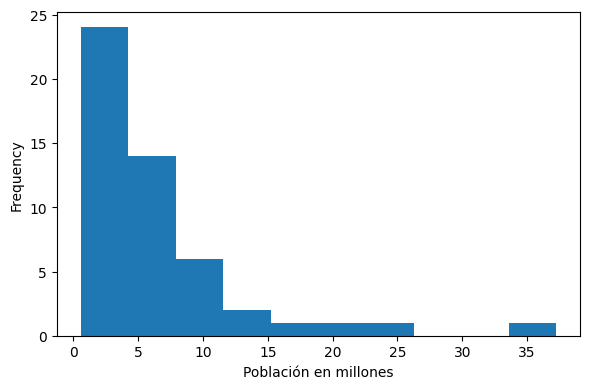

In [ ]:
ax = (estado.Population/1_000_000).plot.hist(figsize=(6,4))
ax.set_xlabel("Población en millones")

plt.tight_layout()

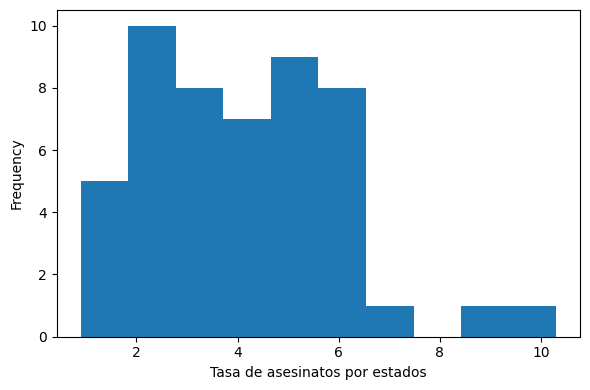

In [ ]:
# Analisis de la nube de datos de la tasa de asesiantos
ax = (estado["Murder.Rate"]).plot.hist(figsize=(6,4))
ax.set_xlabel("Tasa de asesinatos por estados")

plt.tight_layout()

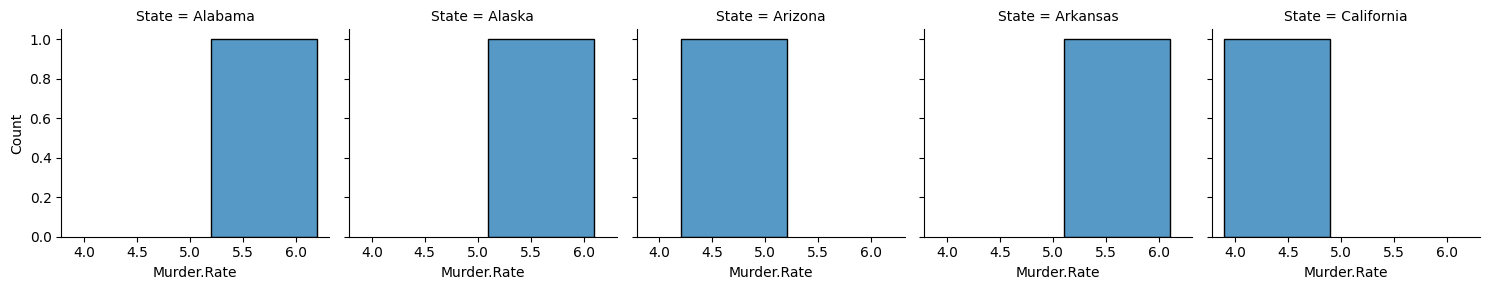

In [ ]:
analisis = estado.head()
g = sns.FacetGrid(analisis, col="State")
g.map(sns.histplot, "Murder.Rate")

**Estimacion de la variabilidad**

Mide el grado de agrupación o dispersión de los datos
  1. Desviación: Distancia entre los valores observados y la estimación de la localización.
  2. Varianza: Suma de los cuadrados de las deviaciones de la media al cuadrado, dividida por n-1, donde n es el número de datos.
  3. Desviación estándar: Raíz cudrada de la varianza.
  4. Desviación media absoluta: Media de los valores absolutos de la desviación media.
  5. Desviación absoluta de la mediana (MAD): Mediana de los valores absolutos de las desviaciones de la mediana.
  6. Rango: Diferencia entre el dato mayory el dato menor.
  7. Percentil: Valor tal que P por ciento de valores, toma ese valor o un valor inferior para 100-P.
  8. Rango intercuartilito (IQR): Diferencia entre el percentil 75 (Q3) y el percentil 25 (Q1).

In [ ]:
# Desviacion estandar
estado.Population.std()

6848235.347401142

In [ ]:
estado["Murder.Rate"].std()

1.915736124302923

In [ ]:
# Calculo del IQR
estado["Population"].quantile(0.75) - estado["Population"].quantile(0.25)

np.float64(4847308.0)

In [ ]:
estado["Murder.Rate"].quantile(0.75) - estado["Murder.Rate"].quantile(0.25)

np.float64(3.125)

**Análisis del Diagrama de Caja y Bigotes (Población)**

El gráfico de caja nos permite observar la distribución y dispersión de la población por estado:
  1. **Mediana (Linea verde):** Indica que la mayoría de los estados tienen una población por debajo de los 5 millones.
  2. **Caja (Rango Intercuartil):** El 50% de los estados se encuentran concentrados en el rango inferior de la escala, lo que muestra una distribución sesgada.
  3. **Outliers (Circulos):** Los puntos en la parte superior representan valores atípicos. Estos son estados cuya población es excepcionalmente alta en comparación con el resto.
  4. **Bigote Superior:** Muestra el límite superior de los datos que no se consideran atípicos.

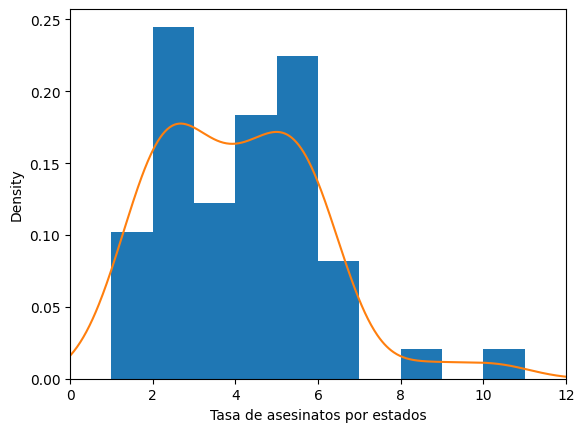

In [ ]:
# Analizar la nube de datos de la tasa de asesinato empleando histogramas y diagramas de densidad
ax = (estado["Murder.Rate"]).plot.hist(density=True, xlim=[0,12],bins=range(1,12))
estado["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("Tasa de asesinatos por estados")

plt.show()

**Tareas**

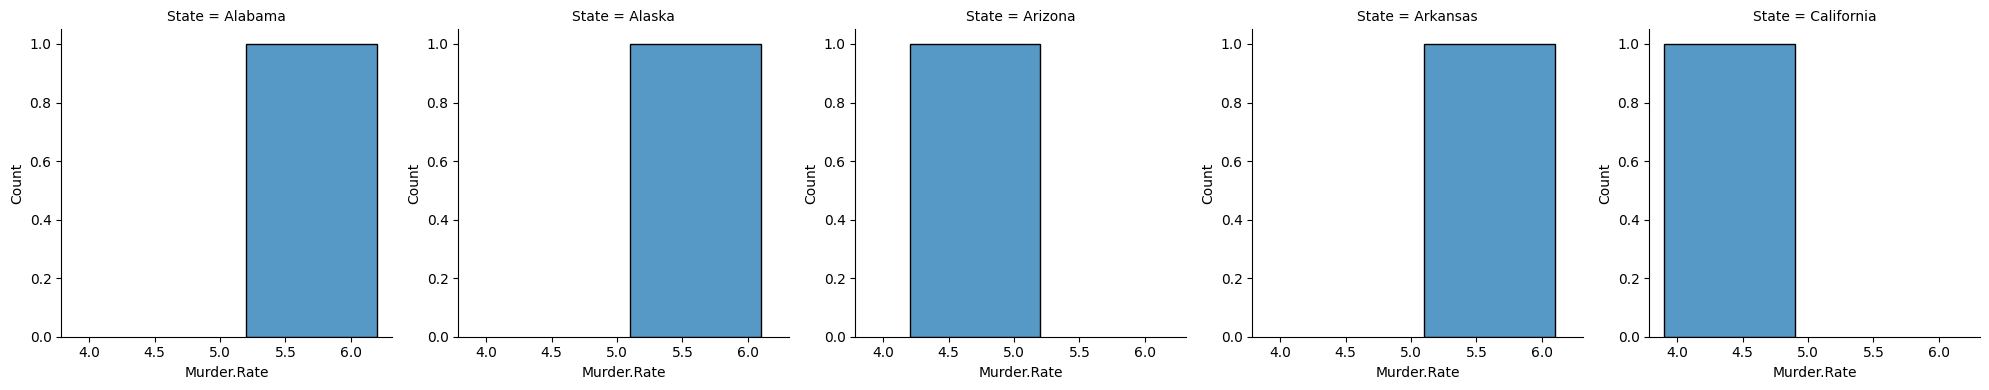

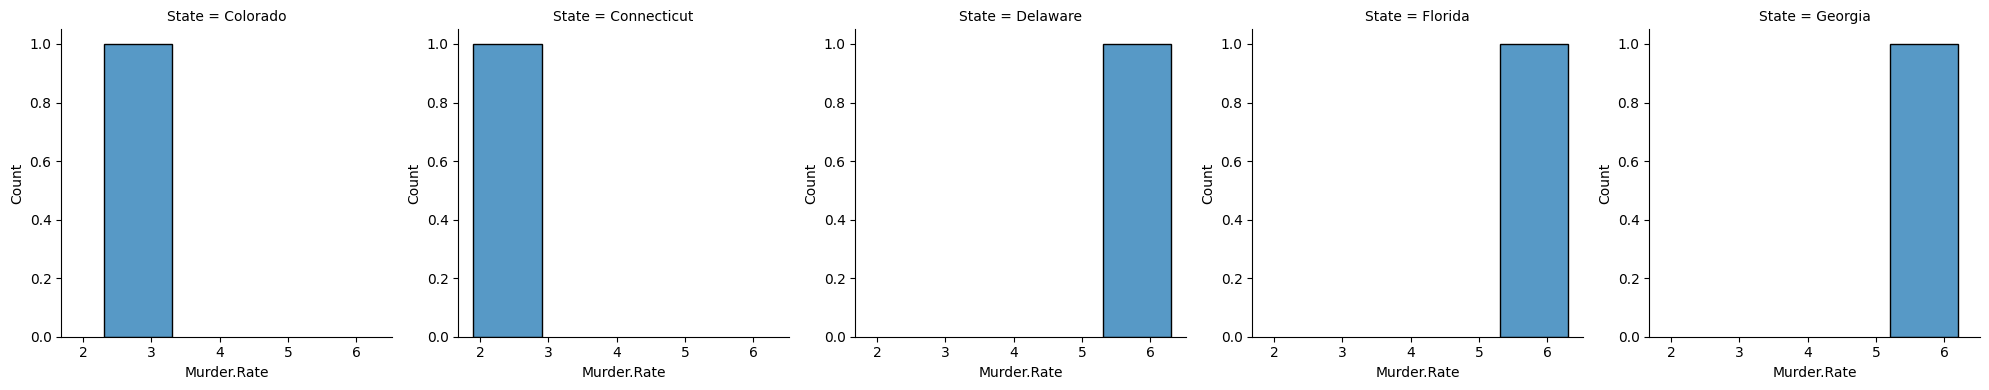

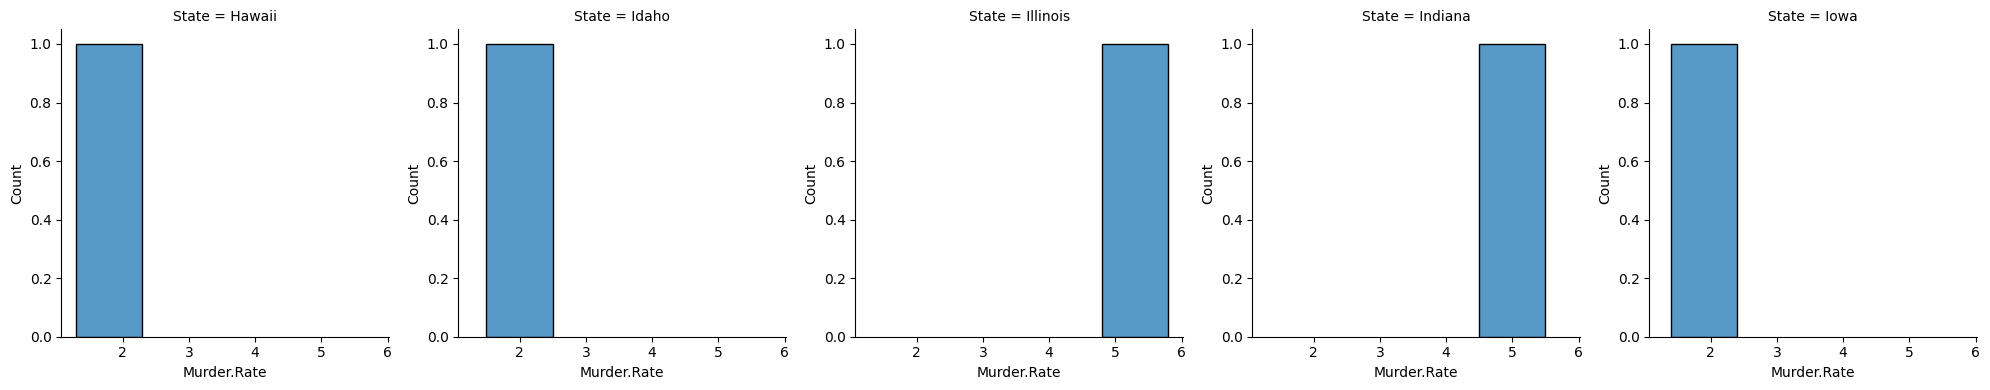

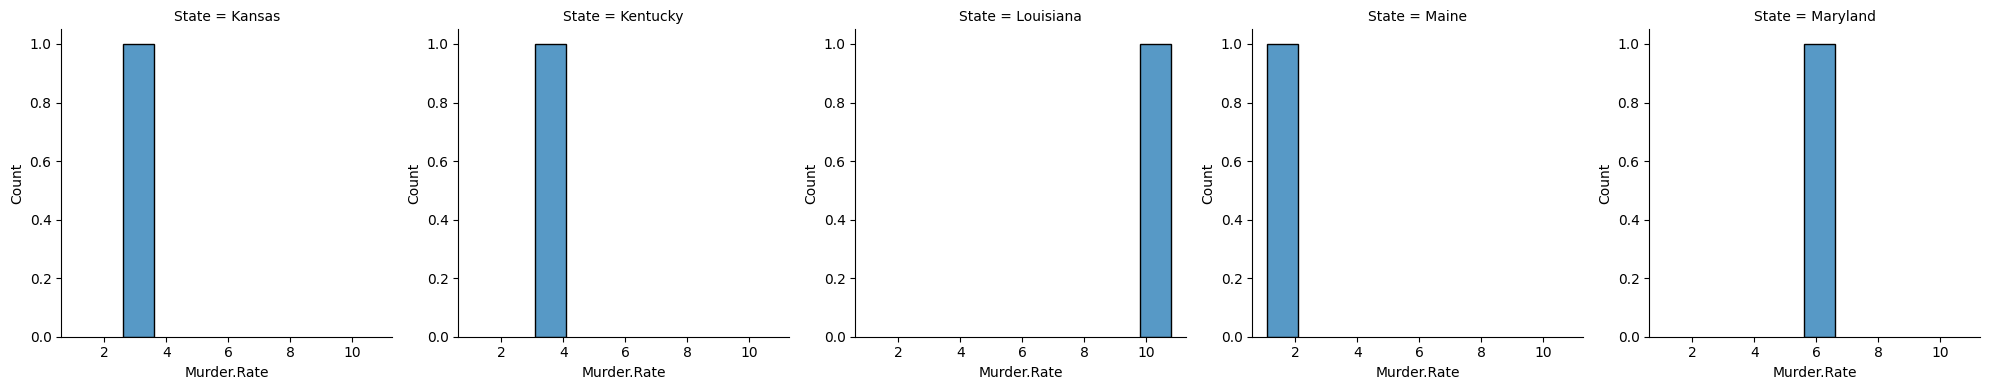

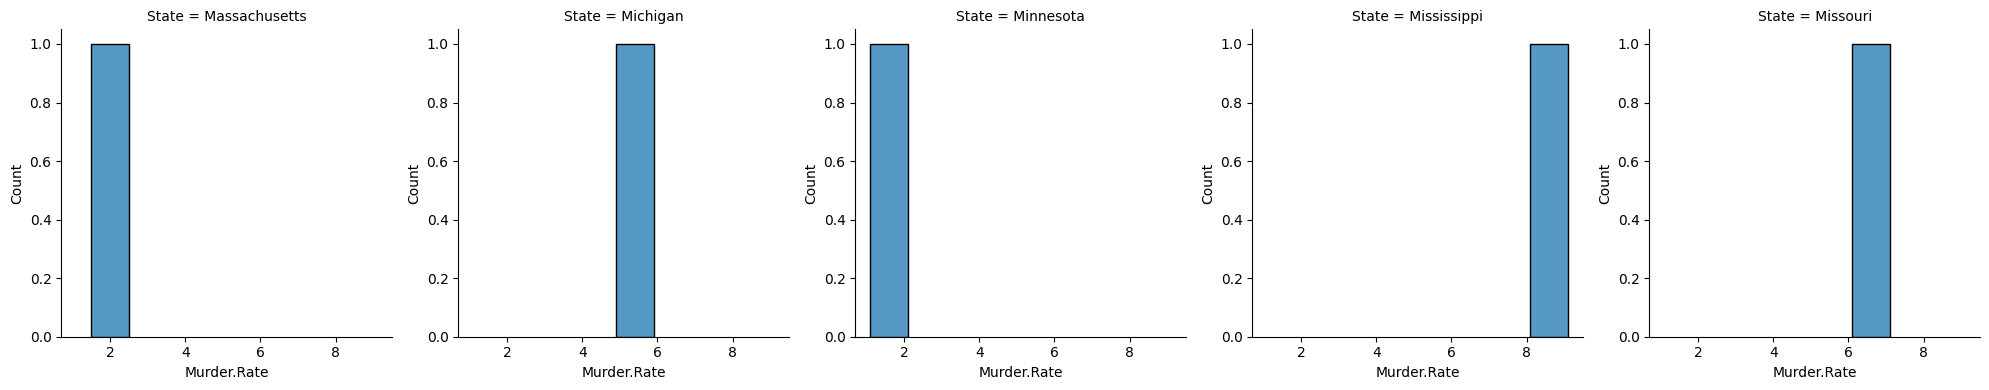

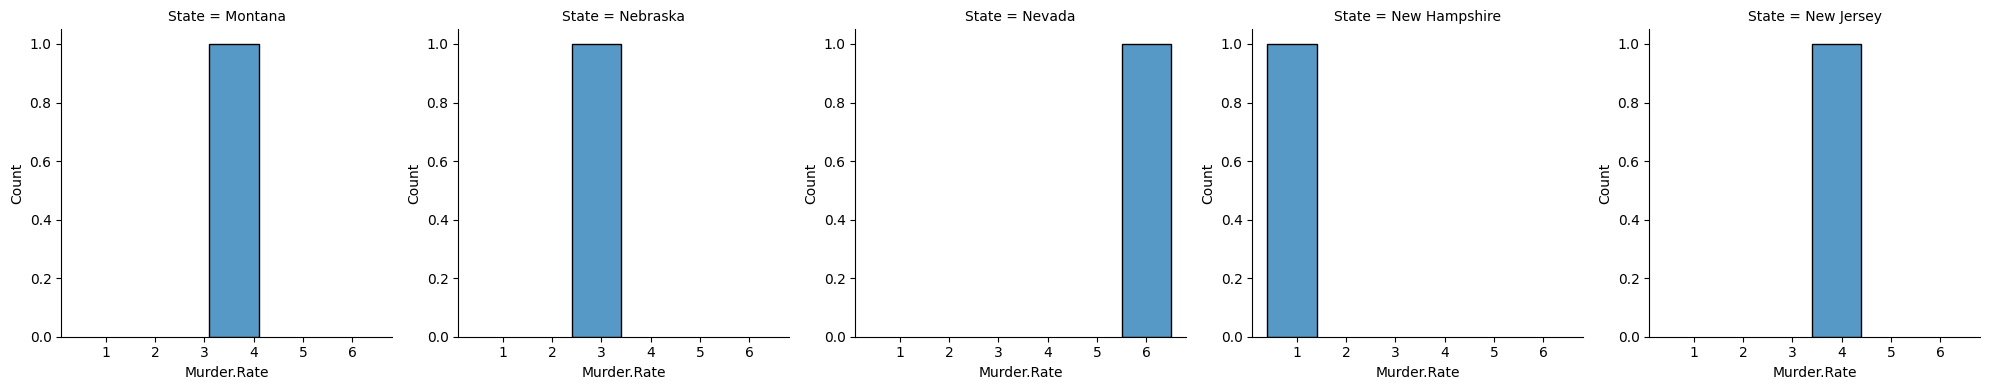

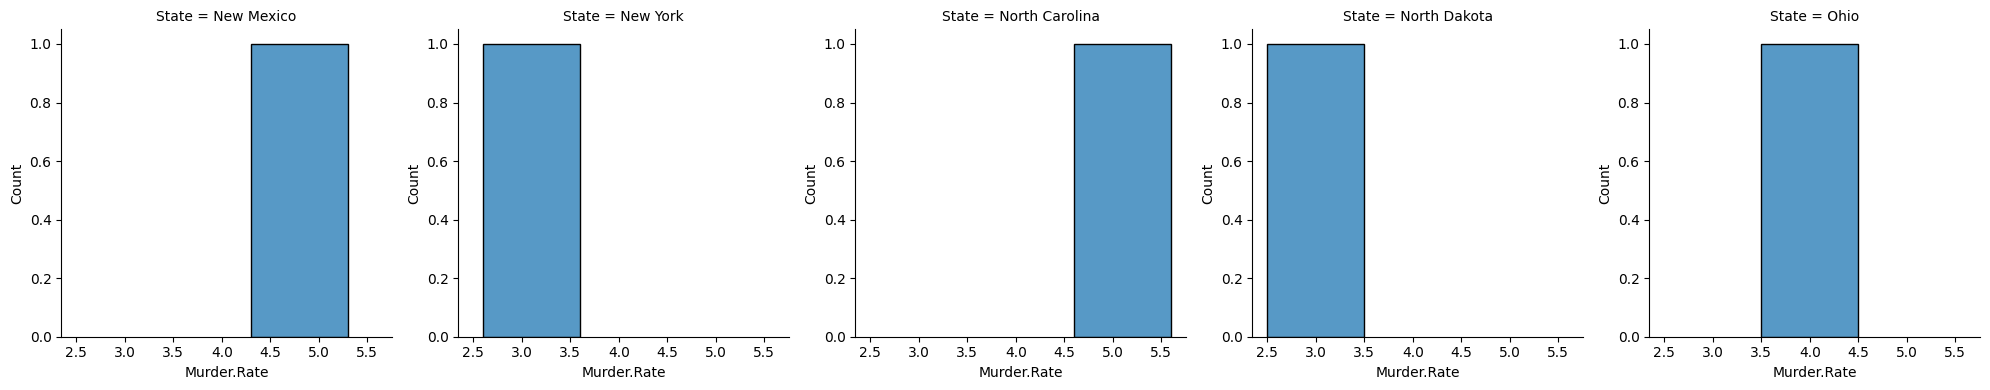

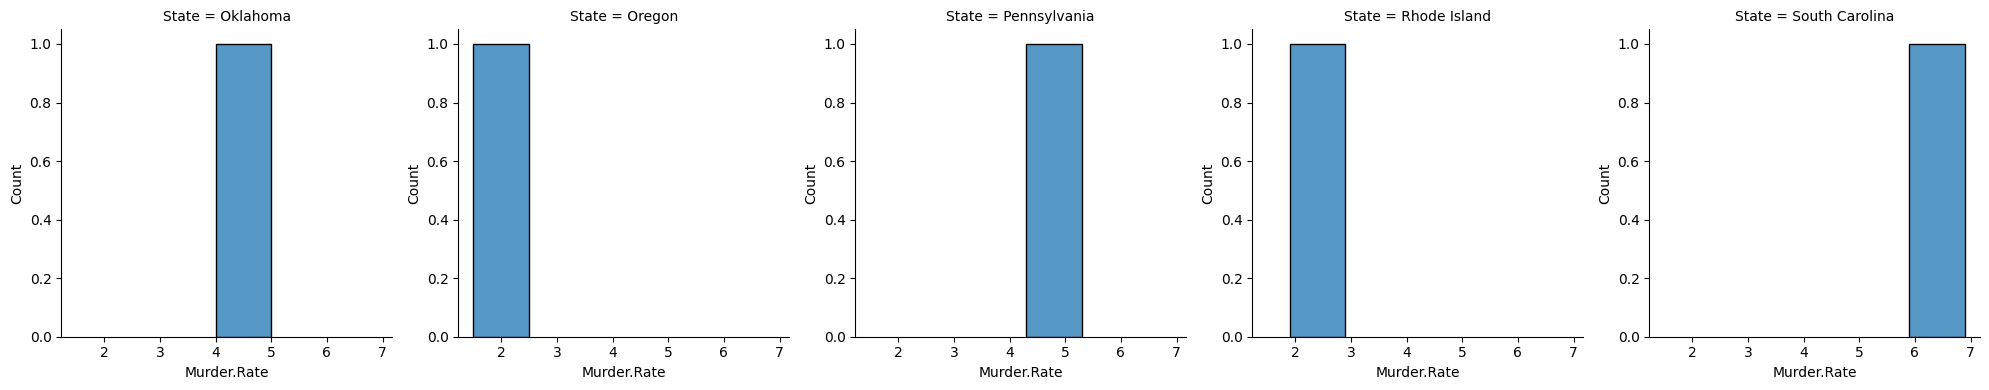

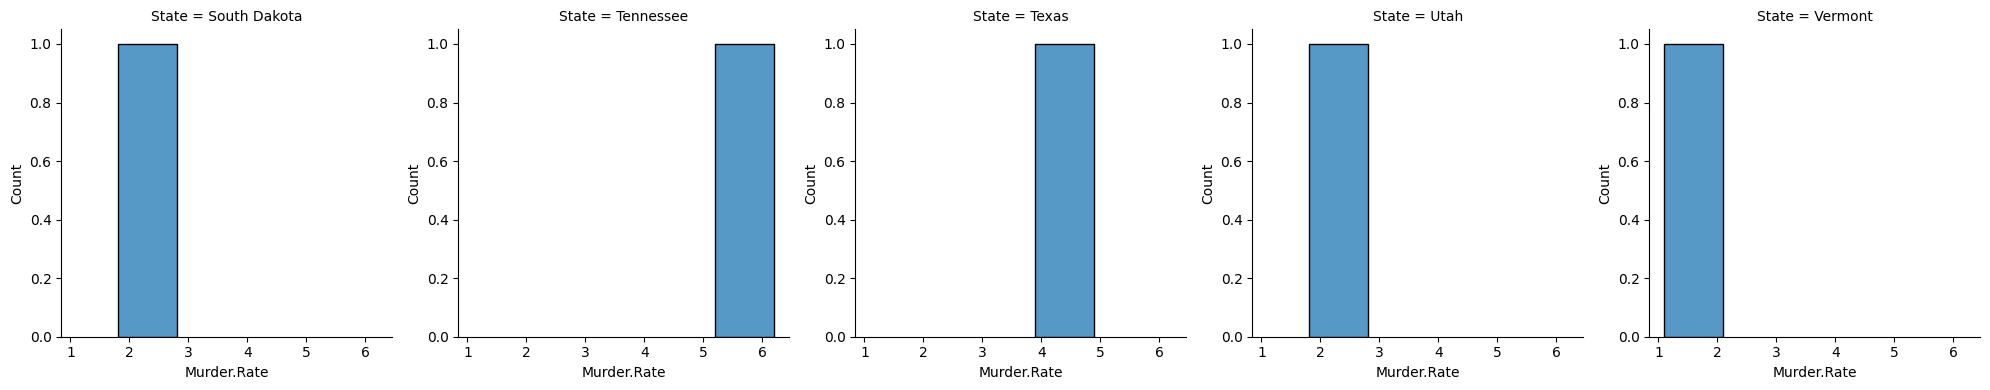

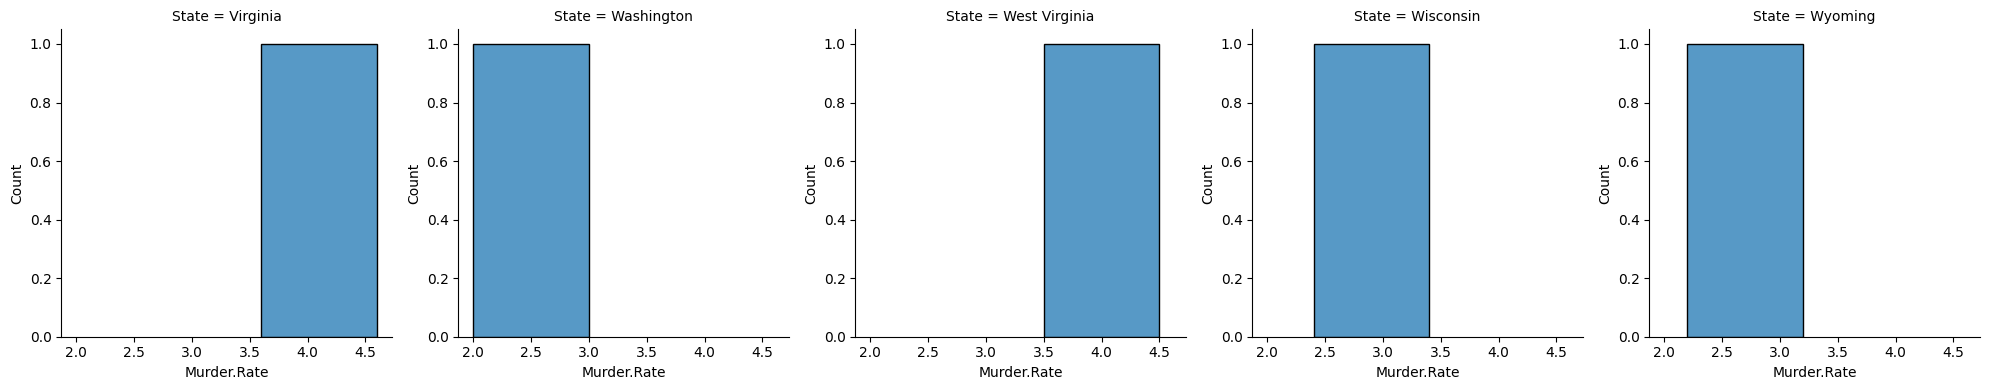

In [ ]:
# Tarea 1: Graficar todos los valores de los estados de 5 en 5
for i in range(0, len(estado), 5):
  analisis_grupo = estado.iloc[i:i+5]
  g = sns.FacetGrid(analisis_grupo, col="State", sharey=False, height=4)
  g.map(sns.histplot, "Murder.Rate")

**EXPLORACION DE DISTRIBUCION DE DATOS USANDO GRAFICOS**
  1. Diagrama de caja: Visualizacion rapida de la distribuciuon de los datos
  2. Diagrama de frecuencia: Registro de recuento de valores de datos numericos que caen en categorias
  3. Histograma: Diagrama de tabla de frecuencias con los intervalos den el eje x y el recuento ( o proporcion ) en el eje y
  4. Diagram de densidad: Version suavizada del histograma
  5. Diagrama de violin: Compara distribucion de probabilidad

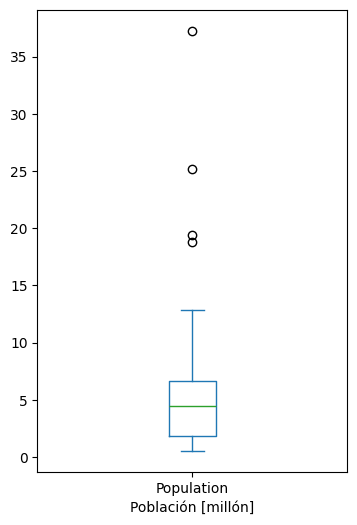

In [ ]:
#Tarea 2: Describir los datos obtenidos del diagrama de caja y bigotes
ax=(estado.Population/1_000_000).plot.box(figsize=(4,6))
ax.set_xlabel("Población [millón]")
plt.show()

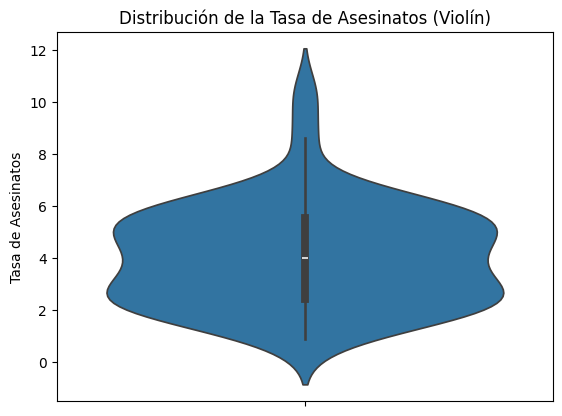

Explicación: El diagrama de violín muestra que la mayor densidad de estados se concentra entre una tasa de 2 y 6. La parte más ancha indica la moda de los datos, y los extremos afinados muestran la menor frecuencia de estados con tasas muy bajas o muy altas (como los outliers detectados anteriormente).


In [ ]:
# Tarea 3: Diagrama de violín de murder rate
ax = sns.violinplot(y=estado["Murder.Rate"])
ax.set_title("Distribución de la Tasa de Asesinatos (Violín)")
ax.set_ylabel("Tasa de Asesinatos")
plt.show()

print("Explicación: El diagrama de violín muestra que la mayor densidad de estados se concentra entre una tasa de 2 y 6. La parte más ancha indica la moda de los datos, y los extremos afinados muestran la menor frecuencia de estados con tasas muy bajas o muy altas (como los outliers detectados anteriormente).")

In [ ]:
# Tarea 4: Estimación de variabilidad robusta (MAD)
mad_population = robust.mad(estado.Population)
mad_murder = robust.mad(estado["Murder.Rate"])

print(f"Desviación Absoluta de la Mediana (MAD) - Población: {mad_population:,.2f}")
print(f"Desviación Absoluta de la Mediana (MAD) - Tasa Asesinatos: {mad_murder:.2f}")

# Comparación con la Desviación Estándar para ver el efecto de los outliers
print(f"\nDesviación Estándar (Población) para comparar: {estado.Population.std():,.2f}")

Desviación Absoluta de la Mediana (MAD) - Población: 3,849,876.15
Desviación Absoluta de la Mediana (MAD) - Tasa Asesinatos: 2.37

Desviación Estándar (Población) para comparar: 6,848,235.35
